In [19]:
# Install and Import Libraries
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
# Step 2 — Load Stock Data from Yahoo Finance
ticker = "AAPL"
df = yf.download(ticker, period="5y")

print(df.shape)
df.head()

/tmp/ipython-input-311/2077382327.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed

(1256, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-03-01,124.466888,124.603247,119.596911,120.531946,116307900
2021-03-02,121.866333,125.372716,121.759193,125.070779,102260900
2021-03-03,118.885895,122.440980,118.671615,121.564383,112966300
2021-03-04,117.006073,120.385838,115.535345,118.583948,178155000
2021-03-05,118.262543,118.769025,114.512661,117.833990,153766600


In [21]:

# Step 2.5 — Fix yfinance MultiIndex Columns
df.columns = df.columns.get_level_values(0)
print(df.columns)  # should show: Open High Low Close Volume
df.head()

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-03-01,124.466888,124.603247,119.596911,120.531946,116307900
2021-03-02,121.866333,125.372716,121.759193,125.070779,102260900
2021-03-03,118.885895,122.440980,118.671615,121.564383,112966300
2021-03-04,117.006073,120.385838,115.535345,118.583948,178155000
2021-03-05,118.262543,118.769025,114.512661,117.833990,153766600


In [29]:
# Step 3 — Improved Feature Engineering
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.dropna(inplace=True)

# Previous days close prices
df['Prev_Close']   = df['Close'].shift(1)
df['Prev_Close_2'] = df['Close'].shift(2)
df['Prev_Close_3'] = df['Close'].shift(3)

# Moving averages
df['MA_5']  = df['Close'].rolling(window=5).mean()
df['MA_10'] = df['Close'].rolling(window=10).mean()

# Price movement features
df['Daily_Change'] = df['Close'] - df['Open']
df['High_Low_Gap'] = df['High']  - df['Low']

# Target = next day closing price
df['Target(Next Day Closing)'] = df['Close'].shift(-1)
df.dropna(inplace=True)

# Features and Target
X = df[['Open', 'High', 'Low', 'Volume',
        'Prev_Close', 'Prev_Close_2', 'Prev_Close_3',
        'MA_5', 'MA_10',
        'Daily_Change', 'High_Low_Gap']]
y = df['Target(Next Day Closing)']

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
df.tail(5)

Features shape: (1236, 11)
Target shape  : (1236,)


Price,Open,High,Low,Close,Volume,Prev_Close,Prev_Close_2,Prev_Close_3,MA_5,MA_10,Daily_Change,High_Low_Gap,Target(Next Day Closing)
Date,,,,,,,,,,,,,
2026-02-19,262.600006,264.480011,260.049988,260.579987,30845300,264.350006,263.880005,255.779999,261.264001,268.363205,-2.020020,4.430023,264.579987
2026-02-20,258.970001,264.750000,258.160004,264.579987,42070500,260.579987,264.350006,263.880005,261.833997,267.255997,5.609985,6.589996,266.179993
2026-02-23,263.489990,269.429993,263.380005,266.179993,37308200,264.579987,260.579987,264.350006,263.913995,266.087997,2.690002,6.049988,272.140015
2026-02-24,267.859985,274.890015,267.709991,272.140015,47014600,266.179993,264.579987,260.579987,265.565997,265.839999,4.280029,7.180023,274.230011
2026-02-25,271.779999,274.940002,271.049988,274.230011,33714300,272.140015,266.179993,264.579987,267.541998,265.895001,2.450012,3.890015,272.950012


In [30]:
 #Step 4 — Train/Test Split (no shuffle for time series!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)

Train size: (988, 11)
Test  size: (248, 11)


In [31]:
# Step 5 — Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("=== Linear Regression ===")
print(f"MAE            : ${mean_absolute_error(y_test, lr_pred):.4f}")
print(f"RMSE           : ${np.sqrt(mean_squared_error(y_test, lr_pred)):.4f}")
print(f"R²             :  {r2_score(y_test, lr_pred):.4f}")
print(f"Average Error  : ${np.mean(np.abs(y_test.values - lr_pred)):.2f}")

=== Linear Regression ===
MAE            : $2.9238
RMSE           : $4.4684
R²             :  0.9764
Average Error  : $2.92


In [32]:
# Step 6 — Train Random Forest Model (Improved)
rf_model = RandomForestRegressor(
    n_estimators=200,      # more trees
    max_depth=10,          # prevent overfitting
    min_samples_split=5,   # smoother predictions
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== Random Forest ===")
print(f"MAE            : ${mean_absolute_error(y_test, rf_pred):.4f}")
print(f"RMSE           : ${np.sqrt(mean_squared_error(y_test, rf_pred)):.4f}")
print(f"R²             :  {r2_score(y_test, rf_pred):.4f}")
print(f"Average Error  : ${np.mean(np.abs(y_test.values - rf_pred)):.2f}")

=== Random Forest ===
MAE            : $8.5026
RMSE           : $11.6229
R²             :  0.8402
Average Error  : $8.50


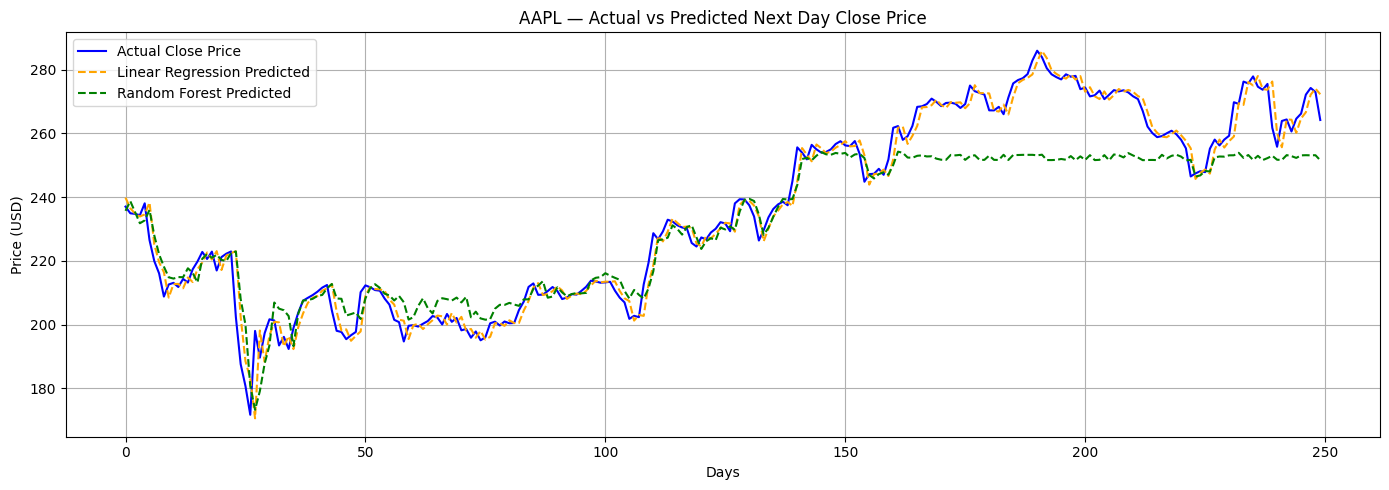

In [26]:
# Step 7 — Plot Actual vs Predicted
plt.figure(figsize=(14, 5))

plt.plot(y_test.values,
         label='Actual Close Price',
         color='blue',
         linewidth=1.5)

plt.plot(lr_pred,
         label='Linear Regression Predicted',
         color='orange',
         linestyle='--',
         linewidth=1.5)

plt.plot(rf_pred,
         label='Random Forest Predicted',
         color='green',
         linestyle='--',
         linewidth=1.5)

plt.title(f"{ticker} — Actual vs Predicted Next Day Close Price")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

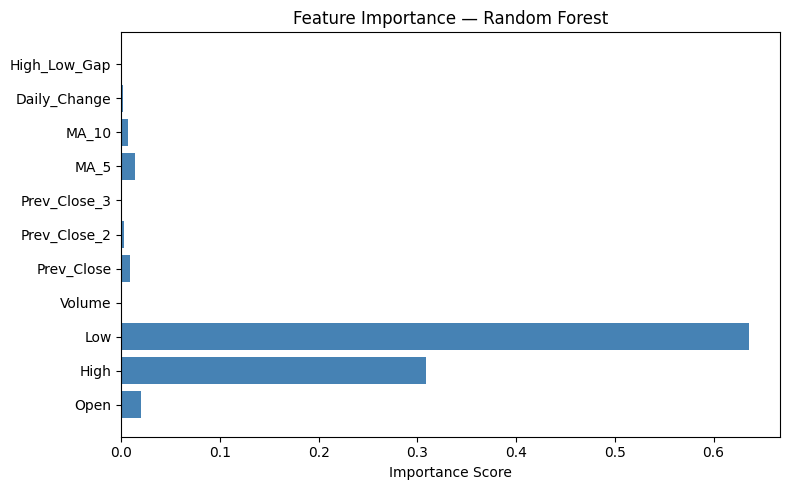

In [27]:
# Step 8 — Feature Importance (Random Forest)
importances = rf_model.feature_importances_
features = list(X.columns)

# Flatten if MultiIndex
features = [str(col) for col in features]

plt.figure(figsize=(8, 5))
plt.barh(features, importances, color='steelblue')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [33]:
# Step 9 — Error Comparison Table
results = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Random Forest'],
    'MAE'    : [mean_absolute_error(y_test, lr_pred),
                mean_absolute_error(y_test, rf_pred)],
    'RMSE'   : [np.sqrt(mean_squared_error(y_test, lr_pred)),
                np.sqrt(mean_squared_error(y_test, rf_pred))],
    'R2'     : [r2_score(y_test, lr_pred),
                r2_score(y_test, rf_pred)],
    'Avg $Error' : [np.mean(np.abs(y_test.values - lr_pred)),
                    np.mean(np.abs(y_test.values - rf_pred))]
})

print(results.to_string(index=False))

            Model      MAE      RMSE       R2  Avg $Error
Linear Regression 2.923828  4.468389 0.976380    2.923828
    Random Forest 8.502622 11.622867 0.840188    8.502622
